# 1. Phase 1: Core Processing

## 1.1. Necessary libraries

In [1]:
#The necessary libraries
from Rulefit_implementation import RuleFitClassifierModel
from sklearn.linear_model import LogisticRegression
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import time
from copy import deepcopy
from sklearn.model_selection import train_test_split, KFold, cross_val_predict, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

from sklearn.metrics import (confusion_matrix,precision_recall_curve,roc_curve,
    auc,roc_auc_score,average_precision_score,accuracy_score,precision_score,recall_score,
    f1_score,classification_report, classification_report,make_scorer)
from Functions_ARIC import preprocess_dataset, impute_data,discretize_continuous_variables, evaluate_and_visualize_model, evaluate_model_cv,count_feature_occurrences, evaluate_and_compare_models  
import xmlrpc.client
import re
from gams import GamsWorkspace 

## Recommendations
changable_feature_ordinal = ['ETHANL03_ordinal', 'CURSMK01_ordinal', 'MOVE_ordinal','P_CARB_ordinal', 'P_PROT_ordinal', 'P_SFAT_ordinal', 'P_TFAT_ordinal','BMI01_ordinal', 'CHOL_ordinal', 'DFIB_ordinal', 'TOTCAL03_ordinal']
ind_changable_ordinal = ['HDLSIU02_ordinal', 'LDLSIU02_ordinal', 'TCHSIU01_ordinal', 'TRGSIU01_ordinal','SBPA21_ordinal', 'SBPA22_ordinal', 'ANTA07A_ordinal','ANTA07B_ordinal', 'ECGMA31_ordinal', 'HMTA03_ordinal',
       'APASIU01_ordinal', 'APBSIU01_ordinal', 'LIPA08_ordinal','CHMA09_ordinal']



## 1.2. Data

In [2]:
## Raw datasets
Total_outcome = pd.read_excel('TotalOutcome.xlsx')
df = pd.read_excel('derive13.xlsx')
# change ID format to match other datasets by removing the 'C' prefix and convert to integer
df['ID_C'] = df['ID_C'].str.replace('C', '').astype(int)

# Feature Groups
required_vars = ['ETHANL03', 'CURSMK01', 'MOVE', 'P_CARB', 'P_PROT', 'P_SFAT', 'P_TFAT','BMI01', 'CHOL', 'DFIB', 'TOTCAL03', 'HDLSIU02', 'LDLSIU02', 'TCHSIU01', 
                 'TRGSIU01', 'SBPA21', 'SBPA22', 'ANTA07A', 'ANTA07B', 'ECGMA31', 'HMTA03','APASIU01', 'APBSIU01', 'LIPA08', 'CHMA09', 'CIGTYR01', 'ELEVEL01', 'GENDER', 
                 'RACEGRP', 'V1AGE01', 'DIABTS', 'HYPERT04', 'HYPTMDCODE01', 'CHOLMDCODE01','ANTA01', 'CIGT01', 'HYPTMD01', 'ANTICOAGCODE01', 'ASPIRINCODE01', 'STATINCODE01'] 
changable_feature = ['ETHANL03', 'CURSMK01', 'MOVE', 'P_CARB', 'P_PROT', 'P_SFAT', 'P_TFAT','BMI01', 'CHOL', 'DFIB', 'TOTCAL03']
ind_changable = ['HDLSIU02', 'LDLSIU02', 'TCHSIU01','TRGSIU01', 'SBPA21', 'SBPA22', 'ANTA07A', 'ANTA07B', 'ECGMA31', 'HMTA03','APASIU01', 'APBSIU01', 'LIPA08', 'CHMA09']
unchangeable= [ 'CIGTYR01', 'ELEVEL01', 'GENDER','RACEGRP', 'V1AGE01', 'DIABTS', 'HYPERT04', 'HYPTMDCODE01', 'CHOLMDCODE01','ANTA01', 'CIGT01', 'HYPTMD01', 'ANTICOAGCODE01', 'ASPIRINCODE01', 'STATINCODE01']
# Merging columns
common_df = df[['ID_C', 'HYPTMD01', 'TOTCAL03', 'CURSMK01','DIABTS02', 'DIABTS03', 'ANTICOAGCODE01', 'ASPIRINCODE01', 'STATINCODE01']].copy()
common_df['DIABTS'] = ((common_df['DIABTS02'] == 1) | (common_df['DIABTS03'] == 1)).astype(int)
# Continious columns
cont_vars = ['BMI01', 'ETHANL03', 'MOVE', 'P_CARB', 'CHOL', 'DFIB', 'P_PROT', 'P_SFAT', 'P_TFAT', 'CIGTYR01', 'HDLSIU02', 'LDLSIU02', 'TCHSIU01', 'TRGSIU01', 'V1AGE01', 'SBPA21', 'SBPA22',
 'ANTA01', 'ANTA07A', 'ANTA07B', 'ECGMA31', 'HMTA03', 'APASIU01', 'APBSIU01', 'LIPA08', 'CHMA09', 'TOTCAL03']
nominal_vars = ['CHOLMDCODE01', 'GENDER', 'HYPERT04', 'RACEGRP', 'HYPTMDCODE01', 'HYPTMD01', 'CURSMK01', 'DIABTS', 'ANTICOAGCODE01', 'ASPIRINCODE01', 'STATINCODE01']
ordinal_vars = ['CIGT01', 'ELEVEL01']

## Processing
Total_outcome = Total_outcome.rename(columns={'CLASS': 'Total_outcome'})
Total_outcome_p = preprocess_dataset(Total_outcome, common_df, required_vars)

Total_outcome_p['HYPTMD01'] = Total_outcome_p['HYPTMD01'].replace('T', np.nan)
Total_outcome_p['CURSMK01'] = Total_outcome_p['CURSMK01'].replace('T', np.nan)

Imputed_DF_total_p= impute_data(Total_outcome_p, cont_vars, nominal_vars, ordinal_vars, iterative_threshold=1)


feature_set = changable_feature + ind_changable

# Discritize all continuous features using 5 bins
discretized_continuous_features, bin_edges = discretize_continuous_variables(Imputed_DF_total_p, feature_set)


# Splitting Data
test_size= 0.3
X = discretized_continuous_features.drop(['Total_outcome', 'ID_C'], axis=1)
y = discretized_continuous_features['Total_outcome']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=test_size, random_state=0,stratify=y)
print(f' 1)Training data {len(X_train)}, 2) Test_data {len(X_test)}')

fnames = X_test.columns


 1)Training data 9557, 2) Test_data 4097


# 2. Phase 2: Machine Learning Models

## 2.1. GBM


Confusion Matrix (Default Threshold = 0.5):
                 Predicted
                 Class 0  Class 1
Actual Class 0:    2946      84
Actual Class 1:     980      87

Confusion Matrix (Optimal Threshold = 0.253499):
                 Predicted
                 Class 0  Class 1
Actual Class 0:    1886    1144
Actual Class 1:     310     757


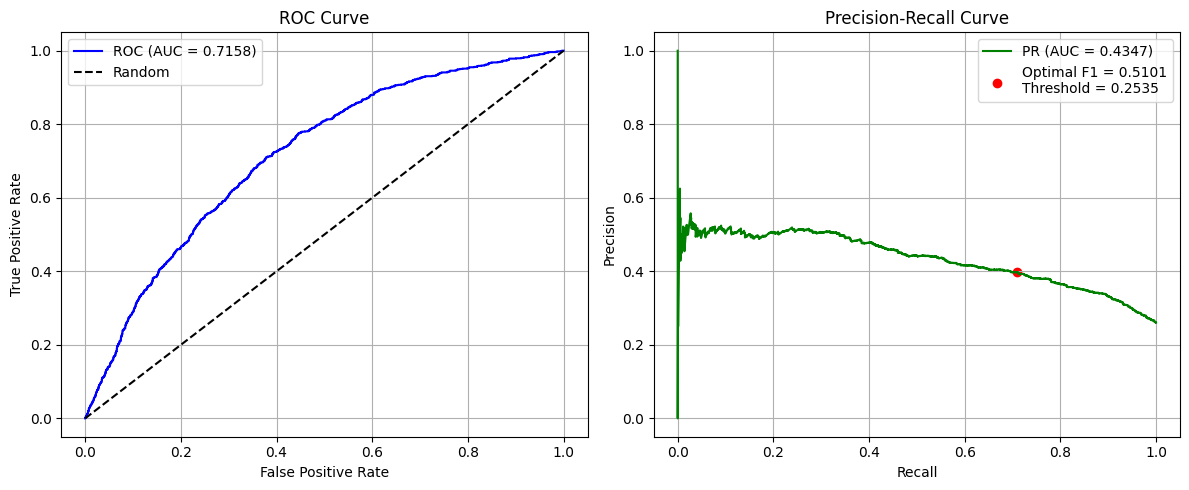


Best F1 Score from PR curve: 0.5101
  Fold 1 | ROC-AUC: 0.6989 | PR-AUC: 0.4171 | F1: 0.5051 | Threshold: 0.2501
  Fold 2 | ROC-AUC: 0.7107 | PR-AUC: 0.4340 | F1: 0.5112 | Threshold: 0.2887
  Fold 3 | ROC-AUC: 0.6997 | PR-AUC: 0.4299 | F1: 0.5045 | Threshold: 0.2238
  Fold 4 | ROC-AUC: 0.7009 | PR-AUC: 0.4362 | F1: 0.4957 | Threshold: 0.2693
  Fold 5 | ROC-AUC: 0.6980 | PR-AUC: 0.4398 | F1: 0.4924 | Threshold: 0.2622

  Avg ROC-AUC : 0.7016 ± 0.0046
  Avg PR-AUC  : 0.4314 ± 0.0078
  Avg F1      : 0.5018 ± 0.0068

  OOF ROC-AUC : 0.7015
  OOF PR-AUC  : 0.4291
  OOF F1      : 0.4947 (threshold=0.2595)
  Confusion Matrix:
[[4487 2580]
 [ 824 1666]]


In [3]:
# Fit gbm model
gbm = GradientBoostingClassifier(
    learning_rate= 0.0022528854683504635,
    max_depth=4,
    min_samples_leaf=20,
    min_samples_split=2,
    n_estimators=1345,
    subsample=0.5,
    random_state=0,
).fit(X_train, y_train)
#gbm_evaluation
gbm_evaluation = evaluate_and_visualize_model(gbm,X_test, y_test)
#cv_gbm
cv_gbm = evaluate_model_cv(gbm, X_train, y_train, cv=5)

## 2.2. Random Forest


Confusion Matrix (Default Threshold = 0.5):
                 Predicted
                 Class 0  Class 1
Actual Class 0:    3030       0
Actual Class 1:    1067       0

Confusion Matrix (Optimal Threshold = 0.258004):
                 Predicted
                 Class 0  Class 1
Actual Class 0:    1823    1207
Actual Class 1:     298     769


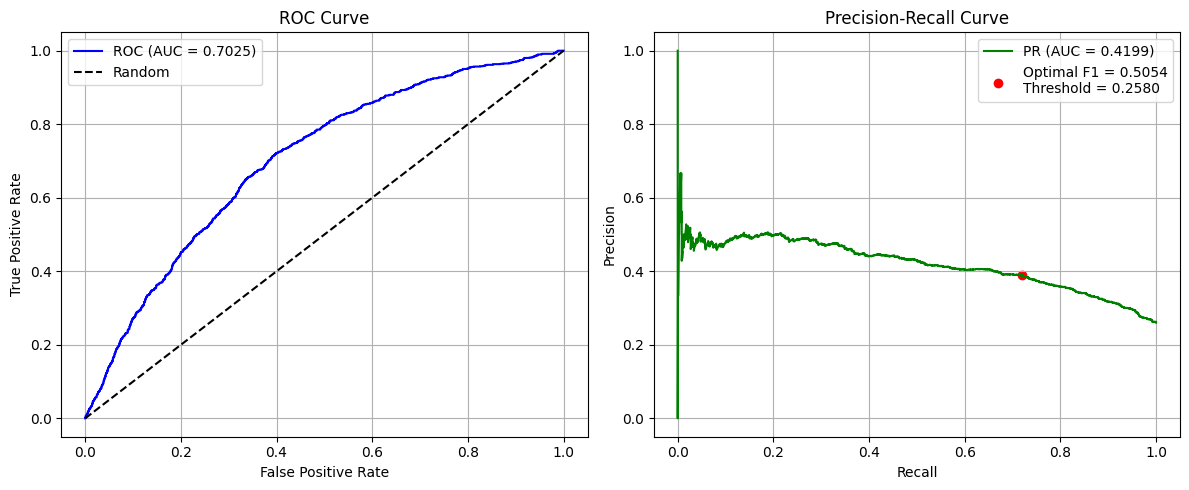


Best F1 Score from PR curve: 0.5054
  Fold 1 | ROC-AUC: 0.6859 | PR-AUC: 0.3994 | F1: 0.4914 | Threshold: 0.2541
  Fold 2 | ROC-AUC: 0.7076 | PR-AUC: 0.4267 | F1: 0.5037 | Threshold: 0.2825
  Fold 3 | ROC-AUC: 0.6922 | PR-AUC: 0.4232 | F1: 0.4854 | Threshold: 0.2693
  Fold 4 | ROC-AUC: 0.6978 | PR-AUC: 0.4435 | F1: 0.4948 | Threshold: 0.2671
  Fold 5 | ROC-AUC: 0.6934 | PR-AUC: 0.4491 | F1: 0.4836 | Threshold: 0.2537

  Avg ROC-AUC : 0.6954 ± 0.0072
  Avg PR-AUC  : 0.4284 ± 0.0175
  Avg F1      : 0.4918 ± 0.0072

  OOF ROC-AUC : 0.6952
  OOF PR-AUC  : 0.4228
  OOF F1      : 0.4881 (threshold=0.2546)
  Confusion Matrix:
[[3981 3086]
 [ 690 1800]]


In [4]:
# Fit rf model
rf = RandomForestClassifier(
    bootstrap= True,
    max_depth= 4,
    max_features= 'log2',
    min_samples_leaf= 7,
    min_samples_split=13,
    n_estimators= 200,
    random_state=0).fit(X_train, y_train)
#rf_evaluation
rf_evaluation = evaluate_and_visualize_model(rf,X_test, y_test)
#cv_rf
cv_rf = evaluate_model_cv(rf, X_train, y_train, cv=5)

## 2.3. XGBoost


Confusion Matrix (Default Threshold = 0.5):
                 Predicted
                 Class 0  Class 1
Actual Class 0:    2962      68
Actual Class 1:     997      70

Confusion Matrix (Optimal Threshold = 0.256600):
                 Predicted
                 Class 0  Class 1
Actual Class 0:    1864    1166
Actual Class 1:     310     757


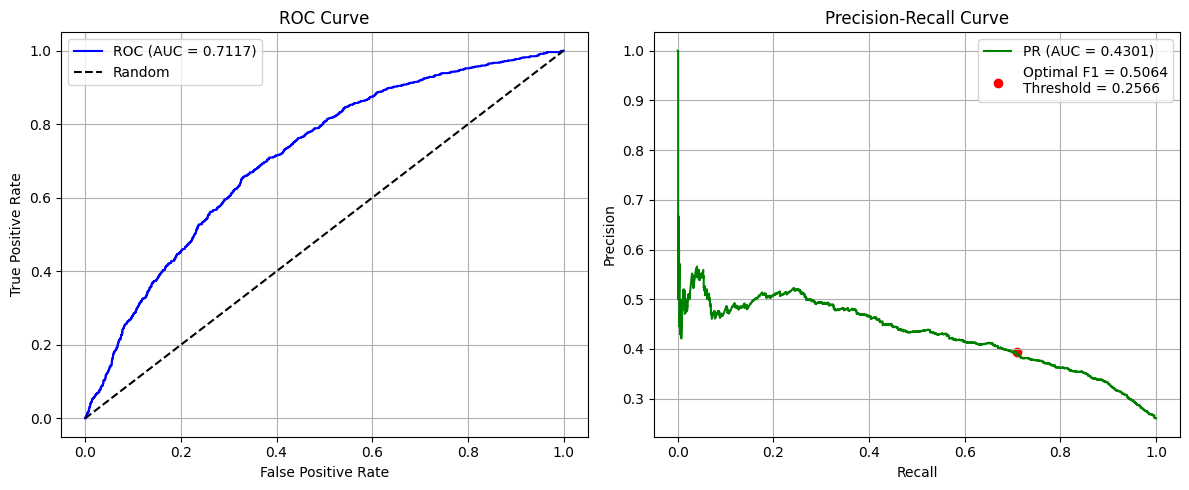


Best F1 Score from PR curve: 0.5064
  Fold 1 | ROC-AUC: 0.6977 | PR-AUC: 0.4155 | F1: 0.4990 | Threshold: 0.2342
  Fold 2 | ROC-AUC: 0.7118 | PR-AUC: 0.4385 | F1: 0.5098 | Threshold: 0.3144
  Fold 3 | ROC-AUC: 0.7018 | PR-AUC: 0.4318 | F1: 0.5059 | Threshold: 0.2548
  Fold 4 | ROC-AUC: 0.6989 | PR-AUC: 0.4405 | F1: 0.4944 | Threshold: 0.2331
  Fold 5 | ROC-AUC: 0.6979 | PR-AUC: 0.4408 | F1: 0.4874 | Threshold: 0.2618

  Avg ROC-AUC : 0.7016 ± 0.0053
  Avg PR-AUC  : 0.4334 ± 0.0095
  Avg F1      : 0.4993 ± 0.0080

  OOF ROC-AUC : 0.7014
  OOF PR-AUC  : 0.4306
  OOF F1      : 0.4959 (threshold=0.2550)
  Confusion Matrix:
[[4271 2796]
 [ 747 1743]]


In [5]:
# Fit xgb model
xgb = XGBClassifier(
    colsample_bytree = 0.5,
    gamma= 8.983211232336584,
    learning_rate= 0.013678424404762761,
    max_depth= 4,
    min_child_weight= 1,
    n_estimators= 3000,
    reg_alpha= 0.08591264116181285,
    reg_lambda= 10.0,
    subsample= 0.8192072367675551).fit(X_train, y_train)
#xgb_evaluation
xgb_evaluation = evaluate_and_visualize_model(xgb,X_test, y_test)
#cv_xgb
cv_xgb = evaluate_model_cv(xgb, X_train, y_train, cv=5)

## 2.4. KNN


Confusion Matrix (Default Threshold = 0.5):
                 Predicted
                 Class 0  Class 1
Actual Class 0:    3011      19
Actual Class 1:    1038      29

Confusion Matrix (Optimal Threshold = 0.240130):
                 Predicted
                 Class 0  Class 1
Actual Class 0:    1606    1424
Actual Class 1:     305     762


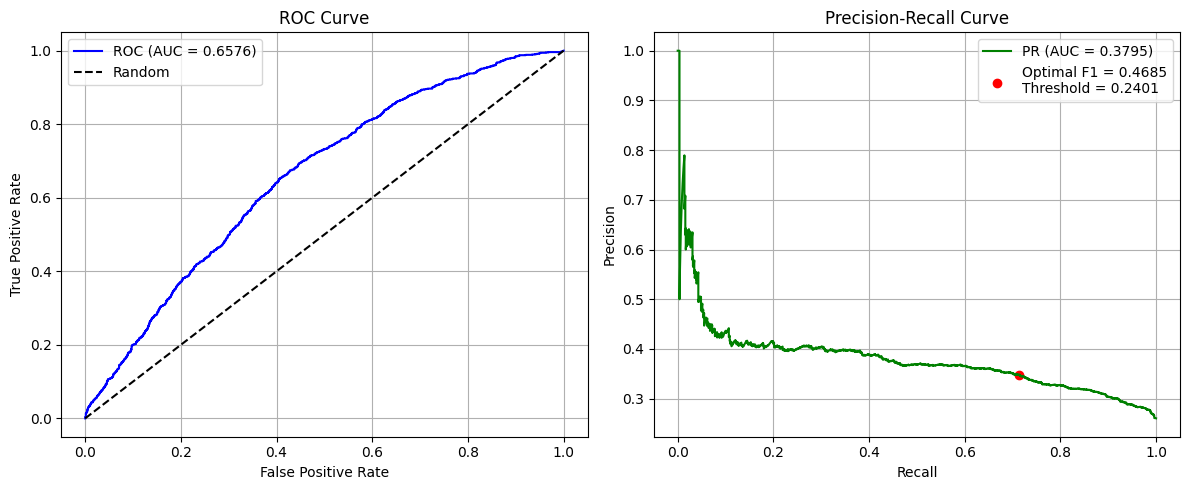


Best F1 Score from PR curve: 0.4685
  Fold 1 | ROC-AUC: 0.6625 | PR-AUC: 0.3806 | F1: 0.4768 | Threshold: 0.2494
  Fold 2 | ROC-AUC: 0.6444 | PR-AUC: 0.3596 | F1: 0.4684 | Threshold: 0.2168
  Fold 3 | ROC-AUC: 0.6180 | PR-AUC: 0.3378 | F1: 0.4537 | Threshold: 0.2062
  Fold 4 | ROC-AUC: 0.6465 | PR-AUC: 0.3656 | F1: 0.4643 | Threshold: 0.2176
  Fold 5 | ROC-AUC: 0.6477 | PR-AUC: 0.3608 | F1: 0.4704 | Threshold: 0.2416

  Avg ROC-AUC : 0.6438 ± 0.0144
  Avg PR-AUC  : 0.3609 ± 0.0137
  Avg F1      : 0.4667 ± 0.0077

  OOF ROC-AUC : 0.6435
  OOF PR-AUC  : 0.3575
  OOF F1      : 0.4625 (threshold=0.2174)
  Confusion Matrix:
[[3220 3847]
 [ 584 1906]]


In [6]:
# Fit knn model
knn = KNeighborsClassifier(
    n_neighbors = 42,
    p = 1,
    weights = 'distance',
    n_jobs=-1).fit(X_train, y_train)
#knn_evaluation
knn_evaluation = evaluate_and_visualize_model(knn, X_test, y_test)
#cv_xgb
cv_knn = evaluate_model_cv(knn, X_train, y_train, cv=5)

## 2.5. LR


Confusion Matrix (Default Threshold = 0.5):
                 Predicted
                 Class 0  Class 1
Actual Class 0:    2889     141
Actual Class 1:     910     157

Confusion Matrix (Optimal Threshold = 0.249200):
                 Predicted
                 Class 0  Class 1
Actual Class 0:    1834    1196
Actual Class 1:     315     752


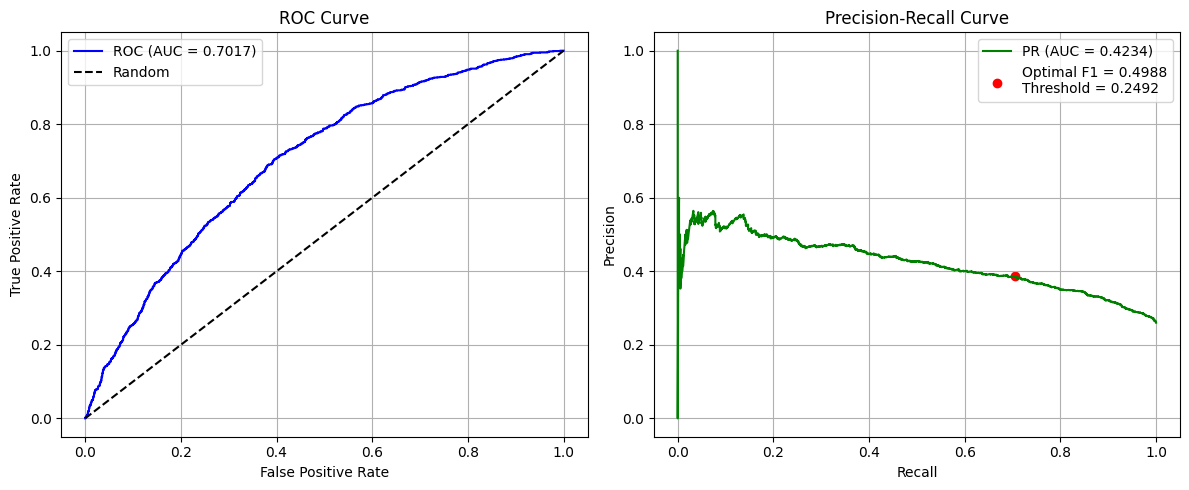


Best F1 Score from PR curve: 0.4988
  Fold 1 | ROC-AUC: 0.7027 | PR-AUC: 0.4336 | F1: 0.4978 | Threshold: 0.2536
  Fold 2 | ROC-AUC: 0.7066 | PR-AUC: 0.4293 | F1: 0.5045 | Threshold: 0.2235
  Fold 3 | ROC-AUC: 0.6981 | PR-AUC: 0.4335 | F1: 0.4878 | Threshold: 0.2425
  Fold 4 | ROC-AUC: 0.6980 | PR-AUC: 0.4229 | F1: 0.4969 | Threshold: 0.2005
  Fold 5 | ROC-AUC: 0.6835 | PR-AUC: 0.4175 | F1: 0.4743 | Threshold: 0.2159

  Avg ROC-AUC : 0.6978 ± 0.0078
  Avg PR-AUC  : 0.4274 ± 0.0063
  Avg F1      : 0.4923 ± 0.0104

  OOF ROC-AUC : 0.6978
  OOF PR-AUC  : 0.4247
  OOF F1      : 0.4897 (threshold=0.2214)
  Confusion Matrix:
[[3737 3330]
 [ 603 1887]]


In [7]:
# Fit lr model
lr_model = LogisticRegression(
    random_state=0,
    n_jobs=-1
).fit(X_train, y_train)
#lr_evaluation
evaluate_and_visualize_model(lr_model, X_test, y_test)
#cv_lr
cv_lr = evaluate_model_cv(lr_model, X_train, y_train, cv=5)


## 2.6. Rulefit

  Candidate rules (post-dedup)  :  1,942
  Selected rules (L1 non-zero)  :    122
  Best alpha (L1 strength)      : 21.544347
  Best C  (= 1 / alpha)         : 0.0464
  Intercept                     : -0.7590

Confusion Matrix (Default Threshold = 0.5):
                 Predicted
                 Class 0  Class 1
Actual Class 0:    2893     137
Actual Class 1:     917     150

Confusion Matrix (Optimal Threshold = 0.236856):
                 Predicted
                 Class 0  Class 1
Actual Class 0:    1766    1264
Actual Class 1:     255     812


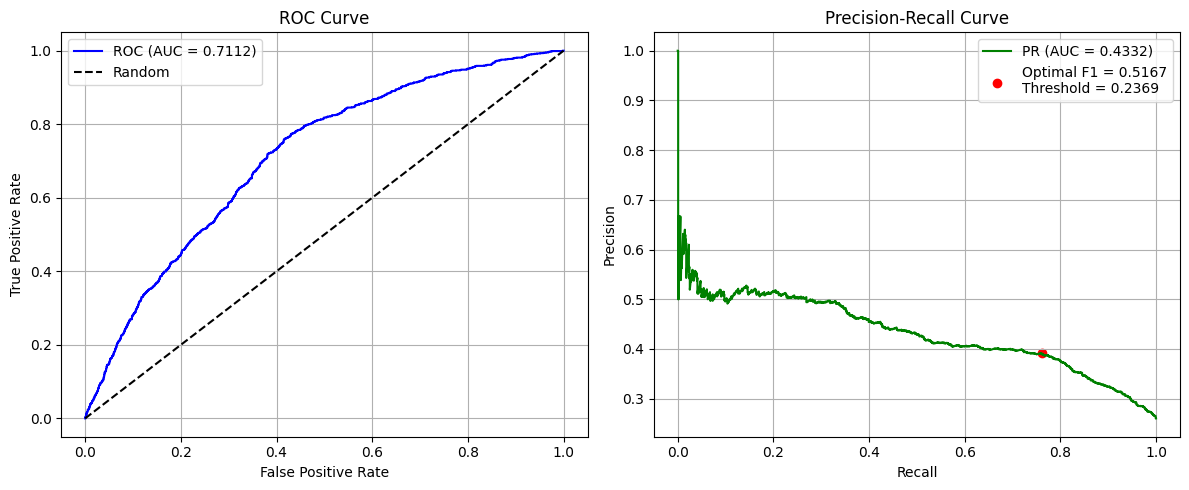


Best F1 Score from PR curve: 0.5167
  Fold 1 | ROC-AUC: 0.6836 | PR-AUC: 0.4062 | F1: 0.4934 | Threshold: 0.2186
  Fold 2 | ROC-AUC: 0.7087 | PR-AUC: 0.4366 | F1: 0.5098 | Threshold: 0.2822
  Fold 3 | ROC-AUC: 0.6872 | PR-AUC: 0.4152 | F1: 0.4901 | Threshold: 0.2394
  Fold 4 | ROC-AUC: 0.6918 | PR-AUC: 0.4276 | F1: 0.4830 | Threshold: 0.2389
  Fold 5 | ROC-AUC: 0.6924 | PR-AUC: 0.4347 | F1: 0.4908 | Threshold: 0.2133

  Avg ROC-AUC : 0.6928 ± 0.0086
  Avg PR-AUC  : 0.4241 ± 0.0117
  Avg F1      : 0.4934 ± 0.0089

  OOF ROC-AUC : 0.6921
  OOF PR-AUC  : 0.4204
  OOF F1      : 0.4881 (threshold=0.2394)
  Confusion Matrix:
[[4146 2921]
 [ 743 1747]]


In [8]:
# Fit rulefit model
crf = RuleFitClassifierModel(
    n_estimators       = 500,
    tree_size          = 4,
    sample_fract       = 0.5,
    max_rules          = 200,
    memory_par         = 0.1,
    cv                 = True,
    elasticnet_l1_ratio = 1, 
    random_state       = 0,
    include_linear     = False,
    n_jobs= -1,
    max_depth= 4).fit(X_train, y_train, feature_names=fnames)
crf.summary()
#rulefit_evaluation
xgb_evaluation = evaluate_and_visualize_model(crf, X_test,y_test)
#cv_rulefit
cv_rulefit = evaluate_model_cv(crf, X_train, y_train, cv=5)

In [9]:
# This counts the number of occurences that lifestyle feature appeared in the rule set.
count_feature_occurrences(crf.get_rules(), feature_set)

{'ETHANL03': 3,
 'CURSMK01': 0,
 'MOVE': 4,
 'P_CARB': 7,
 'P_PROT': 7,
 'P_SFAT': 7,
 'P_TFAT': 5,
 'BMI01': 9,
 'CHOL': 7,
 'DFIB': 1,
 'TOTCAL03': 3,
 'HDLSIU02': 16,
 'LDLSIU02': 6,
 'TCHSIU01': 8,
 'TRGSIU01': 10,
 'SBPA21': 13,
 'SBPA22': 6,
 'ANTA07A': 5,
 'ANTA07B': 14,
 'ECGMA31': 12,
 'HMTA03': 6,
 'APASIU01': 6,
 'APBSIU01': 6,
 'LIPA08': 9,
 'CHMA09': 13}

## 2.7. Models Comparasion

MODEL COMPARISON SUMMARY

--------------------------------------------------------------------------------
MODEL: RuleFit
--------------------------------------------------------------------------------
Metric                    Train           Test            Gap            
----------------------------------------------------------------------
ROC AUC                   0.74            0.71            +0.03
PR AUC                    0.50            0.43            +0.06
Best F1 Score             0.53            0.52            +0.01
Sensitivity (Recall)      0.70            0.76            -0.06
Specificity               0.66            0.58            +0.08
Accuracy                  0.67            0.63            +0.04
Optimal Threshold         0.27            0.24            +0.03

--------------------------------------------------------------------------------
MODEL: Random Forest
--------------------------------------------------------------------------------
Metric              

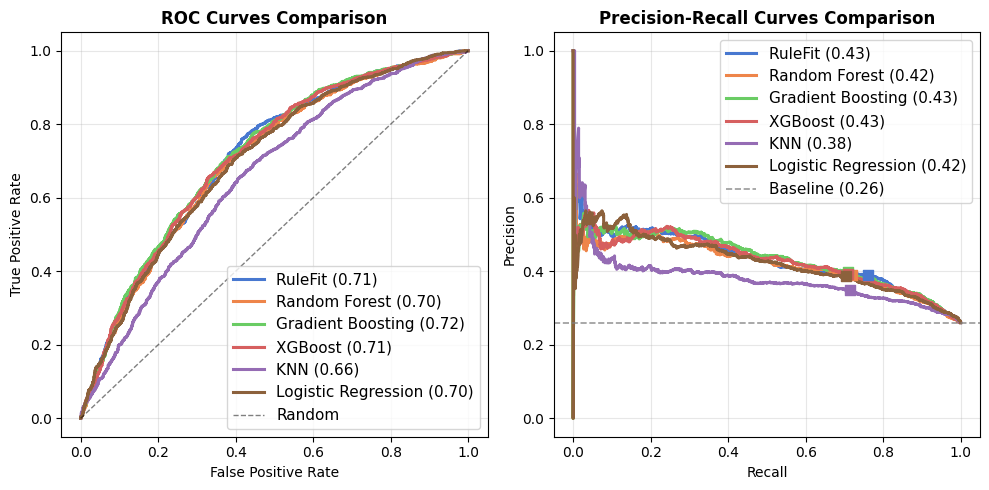


OVERALL COMPARISON (Test Set at Optimal Threshold)
              Model  Optimal_Threshold  ROC_AUC  PR_AUC  F1_Score  Sensitivity_Recall  Specificity  Precision  NPV  Accuracy  TP   TN   FP  FN  ROC_AUC_Gap  PR_AUC_Gap  F1_Gap  Sensitivity_Gap  Specificity_Gap  Accuracy_Gap
            RuleFit               0.24     0.71    0.43      0.52                0.76         0.58       0.39 0.87      0.63 812 1766 1264 255         0.03        0.06    0.01            -0.06             0.08          0.04
      Random Forest               0.26     0.70    0.42      0.51                0.72         0.60       0.39 0.86      0.63 769 1823 1207 298         0.02        0.04   -0.00            -0.04             0.04          0.02
  Gradient Boosting               0.25     0.72    0.43      0.51                0.71         0.62       0.40 0.86      0.65 757 1886 1144 310         0.04        0.10    0.03            -0.03             0.08          0.05
            XGBoost               0.26     0.71    0

In [10]:
comparasion_results, Comparasion_summary_df = evaluate_and_compare_models(
    [crf,rf,gbm,xgb,knn,lr_model],
    ['RuleFit', 'Random Forest', 'Gradient Boosting', 'XGBoost','KNN','Logistic Regression'],
    X_train,
    y_train,
    X_test,
    y_test,
    plot_train_curves=False,
    plot_gap=False,
    title_roc="ROC Curves Comparison",
    title_pr="Precision-Recall Curves Comparison",
    title_gap= 'Generalization Gap',
    round_digits=2,
    width_per_panel= 5,
    show=True,
    save_name= 'Models Performance Comparison on Test Set' )

# 3. Phase 3: Recommendations

## 3.1. Optimization model preparation

In [11]:
# model name crf
from Optimization_Rec_functions import Parameters,calculate_Qj_Uj, calculate_Nj, save_dataframe_to_excel, validate_patient_features, process_decision_rules,embed_rules_vectorized, evaluate_and_apply_recommendations_Lifestyle_ONLY, retrieve_feature_values, generate_and_submit_gams_job, sigmoid  
# identify rulefit model intercept and threshold
intercept = -0.7590 # from crf.summary()
manual_best_threshold = 0.236856 # from crf optimal threshold
# GAMS optimization file
gams_file_path = 'auto_model_2026.gms'

#Process Rules: Controllable and uncontrollable rules
rules_df = crf.get_rules() 
rules_df.rename(columns={'coefficient': 'coef'}, inplace=True)

lifestyle_rules = rules_df[rules_df['rule'].str.contains('ordinal')]
lifstyle_rule_indices_org = lifestyle_rules.index.tolist()
uncontrolable_rule_indices_org = list(set(i for i in range(len(rules_df)))-set(lifstyle_rule_indices_org))
uncontrolable_rules = rules_df.loc[uncontrolable_rule_indices_org]
ordered_rules_df = pd.concat([lifestyle_rules, uncontrolable_rules], ignore_index=True)
ordered_rules_df = ordered_rules_df.reset_index(drop=True)

rules_contains_changeable = []
suffixed_features = [feature + '_ordinal' for feature in changable_feature]

for i in suffixed_features:
    rules_contains_changeable.extend(ordered_rules_df[ordered_rules_df['rule'].str.contains(i)].index.tolist())    
rules_contains_changeable = sorted(list(set(rules_contains_changeable)))

#Embed rules in TEST data
X_test_embeded_T = embed_rules_vectorized(X_test, ordered_rules_df)

encoded_X_test = X_test_embeded_T.copy()
rules_df_sorted = ordered_rules_df.copy()
rule_coefs_ = ordered_rules_df.coef.tolist()
Criterias,B,C,P,A,F,V,D,G,H,S = Parameters(rules_df_sorted.iloc[:len(lifstyle_rule_indices_org),:]) #the parameters generated based on controllable rules only
uncontrolable_indices = [i for i in range(len(lifstyle_rule_indices_org),len(rules_df_sorted))]


## 3.2. Recommendation Generating

### 3.2.1. Bulk patient recommendations generation

In bulk recommendation option, we have two options, either to select subset of the test set (option 1), or select the whole test set or a range (option 2).


In [12]:
sample_patients = [2417,  5107,  12256,  3087, 8397, 10622, 10281,  6016, 9298, 12721]

################################################################
# Option 1: run recommendation on sample_patients indeces only.
################################################################
# Comment this option when run bulk recommendations

output_file = "Output_df_Samples.xlsx" 
samples_df = pd.DataFrame()
samples_df.to_excel(output_file, index=False, engine='openpyxl')
Patient_IDs = sample_patients

################################################################
# Option 2: run recommendation on the whole TEST set "X_test".
################################################################
# output_file = "Output_df_Recommendations.xlsx"  # Or select/write the correct file name
# if os.path.exists(output_file):
#     # Load existing file
#     recommendations_df = pd.read_excel(output_file, engine="openpyxl")
#     print(f"Loaded existing file: {output_file}")
# else:
#     # Create new empty DataFrame and file
#     recommendations_df = pd.DataFrame()
#     recommendations_df.to_excel(output_file, index=False, engine="openpyxl")
#     print(f"Created new file: {output_file}")
#Patient_IDs = X_test.index.tolist()


In [13]:
#############################################################
########## Select supset to run the recommendation ##########
#############################################################

# Patient_IDs=X_test.index.tolist()# Uncomment to Run on the whole test set (make sure to select excel file correctly)
Patient_IDs = sample_patients # Uncomment to Run on the sample patients only (make sure to select excel file correctly)

output_df = pd.read_excel(output_file)
TP,TN,FN,FP= 0,0,0,0 
patients_with_unmet_rules = [] 
TPs, TNs, FNs, FPs = [], [], [], []
patients_with_unmet_rules = []  
infeasible_patients = []
failed_patients = []
g = 0 #Records number
for p in Patient_IDs:
    g += 1
    Patient_index = p
    is_high_risk = sigmoid(np.dot(encoded_X_test.loc[Patient_index].values,rule_coefs_)+intercept)>= manual_best_threshold
    num = max(output_df['Num'].max() + 1, 1) if not output_df.empty else 1 
    # Define the features to be retrieved
    features_to_retrieve = changable_feature_ordinal+ind_changable_ordinal
    org_rules_met = list(np.where(encoded_X_test.loc[Patient_index].values)[0])
    if is_high_risk:
        if y_test[p] == 1:
            TP += 1; TPs.append(p)
        elif y_test[p] == 0:
            FP += 1; FPs.append(p)
        # If high-risk then run on STRR and LTRR    
        for mode in ['STRR', 'LTRR']:
            Q,U = calculate_Qj_Uj(Patient_index, Criterias, X_test, mode, indirectly_changable_features=ind_changable_ordinal, unchangeable_features = unchangeable) # q_j represents if the criteria j should NOT be satisfied {1: Yes, 0: No} and u_j : represents if the criteria j should be satisfied {1: Yes, 0: No}.
            N = calculate_Nj(Patient_index, Criterias, X_test)

            indices_Qj = [i for i, value in enumerate(Q) if value ==1] #criteria indices that need to be 0
            indices_Uj = [i for i, value in enumerate(U) if value ==1] #criteria indices that need to be 1

            jobNumber, password, results, z_values, z_indices, x_values, x_indices,o_value,status = generate_and_submit_gams_job(Patient_index, mode, rules_df_sorted, U, Q, B, C, P, N, A, S, V, D, G, H, gams_file_path, Criterias = Criterias,X_test=X_test) 
            opt_rules = rules_df_sorted.loc[x_indices]
            opt_criteria = [Criterias[j] for j in z_indices]

            # Guard: skip downstream processing if no feasible solution
            if status == 'Infeasible':
                infeasible_patients.append({'patient_id': Patient_index, 'mode': mode, 'job_number': jobNumber})
                print(f"⚠️  Skipping Patient {Patient_index} [{mode}] — Integer Infeasible. No selection made.")
                final_recommendations = validate_patient_features(X_test,Patient_index, opt_criteria, rules_df_sorted, intercept)

                feature_values = retrieve_feature_values(None, features_to_retrieve)
                initial_risk = sigmoid(np.dot(encoded_X_test.loc[Patient_index].values,rule_coefs_)+intercept)

                row = {
                'Num': num,
                'mode': mode,
                'Patient_ID': Patient_index,
                'Class': y_test.loc[Patient_index],
                'is high-risk': 'Yes' if is_high_risk else 'No',
                'Org Risk (RB)':initial_risk,
                'New risk(RB)': initial_risk,  # Placeholder, replace with actual value
                'risk reduction(RB)': 'No Reduction' ,  # Placeholder for original_rb_risk
                'Org Rules met': org_rules_met,
                'Non Opt met': None,  # Could be possible if they are uncontrolable rules
                'Optimal controllable rules': x_indices,  # Only mind the controllable rules
                'Num of modifications': None,
                'Met all opt': None,
                'Total rules met before rec': len(org_rules_met),
                'Total rules met after rec': len(org_rules_met),
                'Non-optimal rules met after modification': None,
                **feature_values,
                'Report':None,
                'Opt Ranges': None,
                'Final Recommendation':final_recommendations
                    }
                # Convert row to DataFrame and append it to df
                row_df = pd.DataFrame([row])
                output_df = pd.concat([output_df, row_df], ignore_index=True)
                save_dataframe_to_excel(output_df, output_file)
                print(f"End of processing of {Patient_index} for {mode} mode.")
                print(f'Current time = {time.localtime()[3:5]}, Num: {num}, Patient ID: {Patient_index}, Mode: {mode}, TP= {TP}, TN= {TN}, FN= {FN}, FP= {FP}, Remaining: {len(Patient_IDs) - g}')
        
                continue
    
            elif status != 'Done':
                failed_patients.append({'patient_id': Patient_index, 'mode': mode, 'job_number': jobNumber, 'reason': status})
                print(f"❌  Skipping Patient {Patient_index} [{mode}] — Job did not complete: {status}.")
                continue

            opt_ranges = process_decision_rules(opt_criteria,Criterias,feature_set)
            final_recommendations = validate_patient_features(X_test,Patient_index, opt_criteria, rules_df_sorted, Criterias, intercept)
            initial_risk,new_risk,conflicts,achievable_rules,fully_met_non_selected,new_to_met,new_to_not_met,risk_changed,org_met,short_report,uncontrolable_met,uncontrolable_Cof = evaluate_and_apply_recommendations_Lifestyle_ONLY(encoded_X_test,X_test, Patient_index, mode, intercept, x_indices, z_indices, A,B, C, indices_Qj, indices_Uj,rules_df_sorted, uncontrolable_indices,lifstyle_rule_indices_org ,print_results=False ,base_0 = True)
            feature_values = retrieve_feature_values(final_recommendations, features_to_retrieve)
        
            met_all_opt = 'No' if conflicts else 'Yes'
            if met_all_opt == 'No':
                patients_with_unmet_rules.append((Patient_index, mode))
                print(f'Patient {Patient_index} has rules conflicts')
                

            
            # Initialize a dictionary to store the feature values
            row = {
            'Num': num,
            'mode': mode,
            'Patient_ID': Patient_index,
            'Class': y_test.loc[Patient_index],
            'is high-risk': 'Yes' if is_high_risk else 'No',
            'Org Risk (RB)':initial_risk,
            'New risk(RB)': new_risk,  # Placeholder, replace with actual value
            'risk reduction(RB)': risk_changed if (risk_changed < 0) else 'No Reduction' ,  # Placeholder for original_rb_risk
            'Org Rules met': org_rules_met,
            'Non Opt met': fully_met_non_selected+uncontrolable_met,  # Could be possible if they are uncontrolable rules
            'Optimal controllable rules': x_indices,  # Only mind the controllable rules
            'Num of modifications': len(final_recommendations),
            'Met all opt': 'Yes' if (achievable_rules == x_indices) else f'No, rules opt and not met: {set(x_indices)-set(achievable_rules)}',
            'Total rules met before rec': len(org_rules_met),
            'Total rules met after rec': len(achievable_rules+uncontrolable_met),
            'Non-optimal rules met after modification': f'Num: {len(uncontrolable_met)}, they are: {uncontrolable_met}', 
            **feature_values,
            'Report':short_report,
            'Opt Ranges': opt_ranges,
            'Final Recommendation':final_recommendations
                }
            # Convert row to DataFrame and append it to df
            row_df = pd.DataFrame([row])
            output_df = pd.concat([output_df, row_df], ignore_index=True)
            save_dataframe_to_excel(output_df, output_file)

            print(f"End of processing of {Patient_index} for {mode} mode.")
            print(f'Current time = {time.localtime()[3:5]}, Num: {num}, Patient ID: {Patient_index}, Mode: {mode}, TP= {TP}, TN= {TN}, FN= {FN}, FP= {FP}, Remaining: {len(Patient_IDs) - g}')
    elif not is_high_risk:
        if y_test[Patient_index] == 1:
            FN += 1; FNs.append(Patient_index)
        elif y_test[Patient_index] == 0:
            TN += 1; TNs.append(Patient_index)

        # Create a row with default values for non high-risk patients
        row = {
            'Num': num,
            'mode': 'NA',
            'Patient_ID': Patient_index,
            'Class': y_test.loc[Patient_index],
            'is high-risk': 'No',
            'Org Risk (RB)': sigmoid(np.dot(encoded_X_test.loc[Patient_index].values,rule_coefs_)+intercept),
            'New risk(RB)': 'Low-Risk - No Recommendations',  # Placeholder for low-risk patients
            'risk reduction(RB)': 'NA',
            'Org Rules met': org_rules_met,
            'Non Opt met': 'NA',  # Could be possible if they are uncontrolable rules
            'Optimal controllable rules': 'NA',  # Only mind  the controllable rules
            'Num of modifications': 0,
            'Met all opt': 'NA',
            'Total rules met before rec': 'NA',
            'Total rules met after rec': 'NA',
            'Non-optimal rules met after modification': 'NA',
            **{feature: 'NA' for feature in features_to_retrieve},  # Assign 'NA' to all features
            'Report': 'No Rec Apply',
            'Opt Ranges': 'No Rec Apply',
            'Final Recommendation': 'No Rec Apply'
        }

        # Convert row to DataFrzame and append it to df
        row_df = pd.DataFrame([row])
        output_df = pd.concat([output_df, row_df], ignore_index=True)
        save_dataframe_to_excel(output_df, output_file)


        print(f"Patient ID: {Patient_index} is Low-Risk. No recommendations applied.")
        print(f'Current time = {time.localtime()[3:5]}, Num: {num}, Patient ID: {Patient_index}, TP= {TP}, TN= {TN}, FN= {FN}, FP= {FP}, Remaining: {len(Patient_IDs) - g}')



Job submitted for patient 2417 at 07:59:32 PM
Job Number: 21749134
Password: CaTKADFq
[07:59:34 PM] Attempt 1: Running
Optimization job for 2417 is Done

Patient 2417 Process Summary: Start Time: 07:59:32 PM, End Time: 07:59:52 PM, Total Duration: 0:00:19.784130, Final Status: Done
File saved successfully to Output_df_Samples.xlsx
End of processing of 2417 for STRR mode.
Current time = (19, 59), Num: 1, Patient ID: 2417, Mode: STRR, TP= 1, TN= 0, FN= 0, FP= 0, Remaining: 9

Job submitted for patient 2417 at 07:59:54 PM
Job Number: 21749153
Password: tpOzwbjq
[07:59:55 PM] Attempt 1: Running
Optimization job for 2417 is Done

Patient 2417 Process Summary: Start Time: 07:59:54 PM, End Time: 08:00:13 PM, Total Duration: 0:00:19.225919, Final Status: Done
File saved successfully to Output_df_Samples.xlsx
End of processing of 2417 for LTRR mode.
Current time = (20, 0), Num: 1, Patient ID: 2417, Mode: LTRR, TP= 1, TN= 0, FN= 0, FP= 0, Remaining: 9

Job submitted for patient 5107 at 08:00:17

### 3.2.2 Single patient recommendation

In [14]:
###########################################################################
########## Select single patient index to run the recommendation ##########
###########################################################################
Patient_index = 2417
output_file_single = "Output_df_Single_Recommendations.xlsx"  # Or select/write the correct file name for single patient recommendation
if os.path.exists(output_file_single):
    # Load existing file
    output_df_single = pd.read_excel(output_file_single, engine="openpyxl")
    print(f"Loaded existing file: {output_file_single}")
else:
    # Create new empty DataFrame and file
    output_df_single = pd.DataFrame()
    output_df_single.to_excel(output_file_single, index=False, engine="openpyxl")
    print(f"Created new file: {output_file_single}")

patients_with_unmet_rules = [] 
patients_with_unmet_rules = []  
infeasible_patients = []
failed_patients = []
num =1

# Evaluate patient risk
is_high_risk = sigmoid(np.dot(encoded_X_test.loc[Patient_index].values,rule_coefs_)+intercept)>= manual_best_threshold

# Define the features to be retrieved
features_to_retrieve = changable_feature_ordinal+ind_changable_ordinal
org_rules_met = list(np.where(encoded_X_test.loc[Patient_index].values)[0])

if is_high_risk:
        
    for mode in ['STRR', 'LTRR']:
        Q,U = calculate_Qj_Uj(Patient_index, Criterias, X_test, mode, indirectly_changable_features=ind_changable_ordinal, unchangeable_features = unchangeable) # q_j represents if the criteria j should NOT be satisfied {1: Yes, 0: No} and u_j : represents if the criteria j should be satisfied {1: Yes, 0: No}.
        N = calculate_Nj(Patient_index, Criterias, X_test)

        
        indices_Qj = [i for i, value in enumerate(Q) if value ==1] #criteria indices that need to be 0
        indices_Uj = [i for i, value in enumerate(U) if value ==1] #criteria indices that need to be 1

        jobNumber, password, results, z_values, z_indices, x_values, x_indices,o_value,status = generate_and_submit_gams_job(Patient_index, mode, rules_df_sorted, U, Q, B, C, P, N, A, S, V, D, G, H, gams_file_path, Criterias = Criterias,X_test=X_test) 
        opt_rules = rules_df_sorted.loc[x_indices]
        opt_criteria = [Criterias[j] for j in z_indices]
    
        # Guard: skip downstream processing if no feasible solution ──────────
        if status == 'Infeasible':
            infeasible_patients.append({'patient_id': Patient_index, 'mode': mode, 'job_number': jobNumber})
            print(f"⚠️  Skipping Patient {Patient_index} [{mode}] — Integer Infeasible. No selection made.")
            final_recommendations = validate_patient_features(X_test,Patient_index, opt_criteria, rules_df_sorted, Criterias, intercept)

            feature_values = retrieve_feature_values(None, features_to_retrieve)
            initial_risk = sigmoid(np.dot(encoded_X_test.loc[Patient_index].values,rule_coefs_)+intercept)
            row = {
            'Num': num,
            'mode': mode,
            'Patient_ID': Patient_index,
            'Class': y_test.loc[Patient_index],
            'is high-risk': 'Yes' if is_high_risk else 'No',
            'Org Risk (RB)':initial_risk,
            'New risk(RB)': 'No Feasible Recommendation',  # Placeholder, replace with actual value
            'risk reduction(RB)': 'No Reduction' ,  # Placeholder for original_rb_risk
            'Org Rules met': org_rules_met,
            'Non Opt met': None,  # Could be possible if they are uncontrolable rules
            'Optimal controllable rules': x_indices,  # Only mind the controllable rules
            'Num of modifications': None,
            'Met all opt': None,
            'Total rules met before rec': len(org_rules_met),
            'Total rules met after rec': len(org_rules_met),
            'Non-optimal rules met after modification': None,
            **feature_values,
            'Report':None,
            'Opt Ranges': None,
            'Final Recommendation':final_recommendations
                }
            # Convert row to DataFrame and append it to df
            row_df = pd.DataFrame([row])
            output_df_single = pd.concat([output_df_single, row_df], ignore_index=True)
            save_dataframe_to_excel(output_df_single, output_file_single)
            continue

        elif status != 'Done':
            failed_patients.append({'patient_id': Patient_index, 'mode': mode, 'job_number': jobNumber, 'reason': status})
            print(f"❌  Skipping Patient {Patient_index} [{mode}] — Job did not complete: {status}.")
            continue


        opt_ranges = process_decision_rules(opt_criteria,Criterias,feature_set)
        final_recommendations = validate_patient_features(X_test, Patient_index, opt_criteria, rules_df_sorted, Criterias, intercept)
        initial_risk,new_risk,conflicts,achievable_rules,fully_met_non_selected,new_to_met,new_to_not_met,risk_changed,org_met,short_report,uncontrolable_met,uncontrolable_Cof = evaluate_and_apply_recommendations_Lifestyle_ONLY(encoded_X_test,X_test, Patient_index, mode, intercept, x_indices, z_indices, A,B, C, indices_Qj, indices_Uj,rules_df_sorted, uncontrolable_indices,lifstyle_rule_indices_org, print_results=False ,base_0 = True)
        feature_values = retrieve_feature_values(final_recommendations, features_to_retrieve)

        met_all_opt = 'No' if conflicts else 'Yes'
        if met_all_opt == 'No':
            patients_with_unmet_rules.append((Patient_index, mode))
            print(f'Patient {Patient_index} has rules conflicts')
              
        # Initialize a dictionary to store the feature values
        row = {
        'Num': num,
        'mode': mode,
        'Patient_ID': Patient_index,
        'Class': y_test.loc[Patient_index],
        'is high-risk': 'Yes' if is_high_risk else 'No',
        'Org Risk (RB)':initial_risk,
        'New risk(RB)': new_risk,  # Placeholder, replace with actual value
        'risk reduction(RB)': risk_changed if (risk_changed < 0) else 'No Reduction' ,  # Placeholder for original_rb_risk
        'Org Rules met': org_rules_met,
        'Non Opt met': fully_met_non_selected+uncontrolable_met,  # Could be possible if they are uncontrolable rules
        'Optimal controllable rules': x_indices,  # Only mind the controllable rules
        'Num of modifications': len(final_recommendations),
        'Met all opt': 'Yes' if (achievable_rules == x_indices) else f'No, rules opt and not met: {set(x_indices)-set(achievable_rules)}',
        'Total rules met before rec': len(org_rules_met),
        'Total rules met after rec': len(achievable_rules+uncontrolable_met),
        'Non-optimal rules met after modification': f'Num: {len(uncontrolable_met)}, they are: {uncontrolable_met}', 
        **feature_values,
        'Report':short_report,
        'Opt Ranges': opt_ranges,
        'Final Recommendation':final_recommendations
            }
        # Convert row to DataFrame and append it to df
        row_df = pd.DataFrame([row])
        output_df_single = pd.concat([output_df_single, row_df], ignore_index=True)
        save_dataframe_to_excel(output_df_single, output_file_single)

        print(f"End of processing of {Patient_index} for {mode} mode.")
        print(f'Current time = {time.localtime()[3:5]}, Num: {num}, Patient ID: {Patient_index}, Mode: {mode}')#, TP= {TP}, TN= {TN}, FN= {FN}, FP= {FP}, Remaining: {len(Patient_IDs) - g}')

elif not is_high_risk:
    row = {
        'Num': num,
        'mode': 'NA',
        'Patient_ID': Patient_index,
        'Class': y_test.loc[Patient_index],
        'is high-risk': 'No',
        'Org Risk (RB)': sigmoid(np.dot(encoded_X_test.loc[Patient_index].values,rule_coefs_)+intercept),
        'New risk(RB)': 'Low-Risk - No Recommendations',  # Placeholder for low-risk patients
        'risk reduction(RB)': 'NA',
        'Org Rules met': org_rules_met,
        'Non Opt met': 'NA',  # Could be possible if they are uncontrolable rules
        'Optimal controllable rules': 'NA',  # Only mind  the controllable rules
        'Num of modifications': 0,
        'Met all opt': 'NA',
        'Total rules met before rec': 'NA',
        'Total rules met after rec': 'NA',
        'Non-optimal rules met after modification': 'NA',
        **{feature: 'NA' for feature in features_to_retrieve},  # Assign 'NA' to all features
        'Report': 'No Rec Apply',
        'Opt Ranges': 'No Rec Apply',
        'Final Recommendation': 'No Rec Apply'
    }

    # Convert row to DataFrame and append it to df
    row_df = pd.DataFrame([row])
    output_df_single = pd.concat([output_df_single, row_df], ignore_index=True)
    save_dataframe_to_excel(output_df_single, output_file_single)
    print(f"Patient ID: {Patient_index} is Low-Risk. No recommendations applied.")
    print(f'Current time = {time.localtime()[3:5]}, Num: {num}, Patient ID: {Patient_index}')#, TP= {TP}, TN= {TN}, FN= {FN}, FP= {FP}, Remaining: {len(Patient_IDs) - g}')
    

 


Created new file: Output_df_Single_Recommendations.xlsx

Job submitted for patient 2417 at 08:07:59 PM
Job Number: 21749456
Password: szAGqQvi
[08:08:01 PM] Attempt 1: Running
Optimization job for 2417 is Done

Patient 2417 Process Summary: Start Time: 08:07:59 PM, End Time: 08:08:18 PM, Total Duration: 0:00:18.958194, Final Status: Done
File saved successfully to Output_df_Single_Recommendations.xlsx
End of processing of 2417 for STRR mode.
Current time = (20, 8), Num: 1, Patient ID: 2417, Mode: STRR

Job submitted for patient 2417 at 08:08:20 PM
Job Number: 21749475
Password: JDxPfuLO
[08:08:22 PM] Attempt 1: Running
Optimization job for 2417 is Done

Patient 2417 Process Summary: Start Time: 08:08:20 PM, End Time: 08:08:40 PM, Total Duration: 0:00:19.438482, Final Status: Done
File saved successfully to Output_df_Single_Recommendations.xlsx
End of processing of 2417 for LTRR mode.
Current time = (20, 8), Num: 1, Patient ID: 2417, Mode: LTRR
